# Active Learning using Laplax

In this example notebook, we demonstrate how laplax can be used to learn a deep neural network actively.

Active learning means to pick the datapoints used for training iteratively and in a smart manner, 
maximizing the information they give the network. \
We start by developing the four core mechanics necessary to do active learning:
1) Sample a target given an x-value from the true function
2) Train the model using a given dataset of points
3) Quantify the uncertainty of a model
4) Find the most informative datapoint from the uncertainty

Part 1) and 2) are identical to what you would do in passive learning, i.e. normally \
Part 3) is where we are going to use laplax. \
For part 4), we are going to use a very simple rule.

Active learning then iterates through these steps in order to learn the function in a data-efficient manner. \
This is especially useful when labelling data is expensive, e.g. when it has to be labelled manually by experts
or aquired through a physics experiment.

In [1]:
from functools import partial

import ipywidgets as widgets
import jax
import optax
from flax import nnx
from helper import DataLoader
from IPython.display import HTML
from jax import numpy as jnp
from jax import random, vmap
from matplotlib import pyplot as plt
from matplotlib.animation import FuncAnimation
from plotting import plot_prediction_with_uncertainty, plot_uncertainty_and_maximum, plot_data_and_uncertainty_around_prediction

from laplax.curv import create_ggn_mv, create_posterior_fn
from laplax.eval.pushforward import (
    lin_pred_mean,
    lin_pred_std,
    lin_pred_var,
    lin_setup,
    set_lin_pushforward,
)
from laplax.eval.calibrate import optimize_prior_prec
from laplax.eval import evaluate_for_given_prior_arguments
from laplax.eval.metrics import nll_gaussian


seed = 2392385

We first choose a function that we want to learn, for now a simple 1D to 1D function, the sinus cardinalis. \
We define a function that computes the value of the function at a given point, and adds Gaussian measurement noise.

In [2]:
var_widget = widgets.FloatLogSlider(
    value=0.01, base=10, min=-4, max=-1, step=0.5, description="Variance"
)
display(var_widget)

FloatLogSlider(value=0.01, description='Variance', max=-1.0, min=-4.0, step=0.5)

In [3]:
sample_variance = var_widget.value
print("Sample variance: ", sample_variance)


def sample_target(x, key, sample_variance=0.0005):
    """Sample a target (label) for a given datapoint x.

    Args:
        x: x-value for which to sample a label
        key: PRNGKey to use for sampling
        sample_variance: Strength of added noise

    Returns:
        $y = f(x) + eps$ where $f$ is the sinc function
        and eps is Gaussian noise with mean zero and variance given by 'sample_variance'
    """
    x = x.squeeze()  # Assume one-dimensional x values
    y_true = jnp.sinc(x)
    noise = random.normal(key, y_true.shape) * jnp.sqrt(sample_variance)
    return y_true + noise


# Function without noise
def true_function(xs):
    key = random.key(seed)
    keys = random.split(key, len(xs))

    function = partial(sample_target, sample_variance=0.0)
    return vmap(function)(xs, keys)


# Initial dataset
x = jnp.concatenate((jnp.linspace(0.2, 2, 2), jnp.linspace(3.5, 5, 2)))[:, None]
x = x.astype(float)
n_initial_datapoints = x.shape[0]

key = random.key(seed)
keys = random.split(key, len(x))

sample = partial(sample_target, sample_variance=sample_variance)
y = vmap(sample)(x, keys)[:, None]

dataloader = DataLoader(x, y, batch_size=10)

Sample variance:  0.01


Next, we define our deep neural network and its training loop.\
Here, we use a network of 6 fully connected layers with a hidden dimension of 64.

In [4]:
# Model definition


class Model(nnx.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, rngs):
        self.linear1 = nnx.Linear(in_channels, hidden_channels, rngs=rngs)
        self.linear2 = nnx.Linear(hidden_channels, hidden_channels, rngs=rngs)
        self.linear3 = nnx.Linear(hidden_channels, hidden_channels, rngs=rngs)
        self.linear4 = nnx.Linear(hidden_channels, out_channels, rngs=rngs)

    def __call__(self, x):
        x = nnx.tanh(self.linear1(x))
        x = nnx.tanh(self.linear2(x))
        x = nnx.tanh(self.linear3(x))
        return self.linear4(x)


@nnx.jit
def train_step(model, optimizer, x, y):
    def loss_fn(model):
        y_pred = model(x)
        return jnp.sum((y_pred - y) ** 2)

    loss, grads = nnx.value_and_grad(loss_fn)(model)
    optimizer.update(grads)

    return loss


model = Model(in_channels=1, hidden_channels=32, out_channels=1, rngs=nnx.Rngs(seed))

params = nnx.state(model)
total_params = sum(p.size for p in jax.tree.leaves(params))
print(f"Total number of parameters: {total_params}")

Total number of parameters: 2209


In [5]:
def train_model(model, dataloader, n_epochs=1000, lr=1e-3):
    """Trains the given model on the data.

    Args:
        model: nnx.Module that represents the model, can be pretrained
        dataloader: Data on which to train
        n_epochs: Number of epochs to train for
        lr: learning rate for optimizer

    Returns:
        Trained model
    """
    optimizer = nnx.Optimizer(model, optax.adam(lr))

    for epoch in range(n_epochs):
        for x_batch, y_batch in dataloader:
            loss = train_step(model, optimizer, x_batch, y_batch)

        if epoch % 100 == 0 and epoch != 0:
            print(f"[epoch {epoch}]: loss: {loss:.4f}")
    print(f"Final loss: {loss:.4f}")
    return model


n_initial_epochs = 400

model = train_model(model, dataloader, n_epochs=n_initial_epochs)

[epoch 100]: loss: 0.0201
[epoch 200]: loss: 0.0124
[epoch 300]: loss: 0.0039
Final loss: 0.0005


Now that we have trained the network on the initial dataset, we can visualize it:

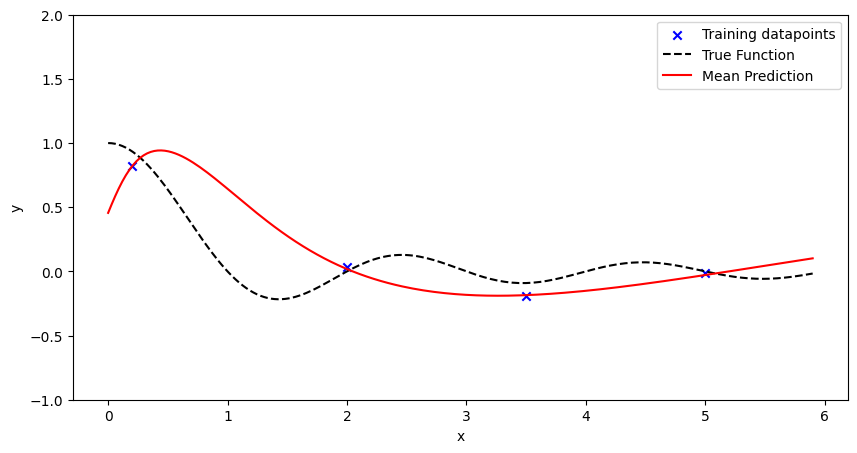

In [6]:
# Trained model visualization

x_pred = jnp.linspace(0.0, 5.9, 200)[:, None]

y_true = true_function(x_pred)
y_pred = model(x_pred)

fig, ax = plt.subplots(figsize=(10, 5))
plot_prediction_with_uncertainty(ax, dataloader, x_pred, y_true, y_pred, None)
plt.show()

The model fits the four datapoints well, but it does of course not match the true function well, because it has not seen enough data yet.

### Calibrating the prior precision

In [7]:
lib_dropdown = widgets.Dropdown(
    options=["full", "diagonal", "lanczos", "lobpcg"],
    value="full",
    description="Curv. est.:",
)
display(lib_dropdown)

Dropdown(description='Curv. est.:', options=('full', 'diagonal', 'lanczos', 'lobpcg'), value='full')

In [8]:
print(f"Curvature will be estimated using a {lib_dropdown.value} approximation.")
curv_type = lib_dropdown.value
low_rank_args = {
    "key": random.key(20),
    "rank": 50,
    "mv_jit": True,
}
curv_args = {} if curv_type in {"full", "diagonal"} else low_rank_args


Curvature will be estimated using a full approximation.


In [9]:
graph_def, params = nnx.split(model)

def model_fn(input, params):
    return nnx.call((graph_def, params))(input)[0]

clbr_batch = {"input": dataloader.X, "target": dataloader.y}

ggn_mv = create_ggn_mv(
    model_fn,
    params,
    clbr_batch,
    loss_fn="mse",
)

posterior_fn = create_posterior_fn(
    curv_type=curv_type,
    mv=ggn_mv,
    layout=params,
    **curv_args,
)

set_prob_predictive = partial(
    set_lin_pushforward,
    model_fn=model_fn,
    mean_params=params,
    posterior_fn=posterior_fn,
    pushforward_fns=[
        lin_setup,
        lin_pred_mean,
        lin_pred_std,
    ],
)

@jax.jit
def nll_objective(prior_arguments, batch):
    return evaluate_for_given_prior_arguments(
        prior_arguments=prior_arguments,
        data=batch,
        set_prob_predictive=set_prob_predictive,
        metric=nll_gaussian,
    )

# Optimize via grid search
prior_prec = optimize_prior_prec(
    objective=partial(nll_objective, batch=clbr_batch),
    log_prior_prec_min=2.0,
    log_prior_prec_max=7.0,
    grid_size=50,
)

print("Calibrated prior precision: ", prior_prec)


2026-02-02 14:19:24.500 | INFO     | laplax.eval.calibrate:grid_search:110 - Took 0.5812 seconds, prior prec: 100.0000, result: -0.151003
2026-02-02 14:19:24.676 | INFO     | laplax.eval.calibrate:grid_search:110 - Took 0.1751 seconds, prior prec: 126.4855, result: -0.200931
2026-02-02 14:19:24.860 | INFO     | laplax.eval.calibrate:grid_search:110 - Took 0.1825 seconds, prior prec: 159.9858, result: -0.254568
2026-02-02 14:19:25.054 | INFO     | laplax.eval.calibrate:grid_search:110 - Took 0.1934 seconds, prior prec: 202.3590, result: -0.312365
2026-02-02 14:19:25.238 | INFO     | laplax.eval.calibrate:grid_search:110 - Took 0.1833 seconds, prior prec: 255.9547, result: -0.374729
2026-02-02 14:19:25.437 | INFO     | laplax.eval.calibrate:grid_search:110 - Took 0.1982 seconds, prior prec: 323.7458, result: -0.441980
2026-02-02 14:19:25.680 | INFO     | laplax.eval.calibrate:grid_search:110 - Took 0.2422 seconds, prior prec: 409.4915, result: -0.514313
2026-02-02 14:19:25.870 | INFO    

Calibrated prior precision:  471485.78


Now, to decide where to sample the next datum, we need the uncertainty of the model in the target variable space.\
We aquire this using laplax by approximating the weight space uncertainty via a curvature matrix and subsequently pushing it forward into the target variable space.\
You can choose how the curvature matrix shall be approximated from the options implemented in laplax and see\
how this affects the uncertainty and performance of active learning.

Our network has 2209 parameters, so the full curvature matrix would have $2209^2 \cdot 4 \text{ byte} = 19.5 \text{ MB}$.

In [10]:
def quantify_uncertainty(model, trainloader, x_pred, prior_precision):
    """Compute uncertainty of model on x_pred using laplax.

    Args:
        model: Model whose uncertainty is to be quantified
        trainloader: Datapoints used for training of model
        x_pred: Points where to quantify uncertainty
        prior_precision: Precision of assumed prior

    Returns:
        Tuple of prediction and its uncertainty (standard deviation)
    """
    graph_def, params = nnx.split(model)

    def model_fn(input, params):
        return nnx.call((graph_def, params))(input)[0]

    trainset = {"input": trainloader.X, "target": trainloader.y}

    ggn_mv = create_ggn_mv(
        model_fn,
        params,
        trainset,
        loss_fn="mse",
    )

    posterior_fn = create_posterior_fn(
        curv_type=curv_type,
        mv=ggn_mv,
        layout=params,
        **curv_args,
    )

    set_prob_predictive = partial(
        set_lin_pushforward,
        model_fn=model_fn,
        mean_params=params,
        posterior_fn=posterior_fn,
        pushforward_fns=[
            lin_setup,
            lin_pred_mean,
            lin_pred_var,
            lin_pred_std,
        ],
    )
    prior_arguments = {"prior_prec": prior_precision}
    prob_predictive = set_prob_predictive(
        prior_arguments=prior_arguments,
    )

    pred = jax.vmap(prob_predictive)(x_pred)
    y_mean = pred["pred_mean"][:, 0]
    y_std = jnp.sqrt(pred["pred_var"][:, 0])

    return y_mean, y_std


#prior_prec = 1.0 / sample_variance # Uncalibrated

y_mean, y_std = quantify_uncertainty(model, dataloader, x_pred, prior_prec)

We plot the learned network again, this time with the computed and calibrated uncertainty.

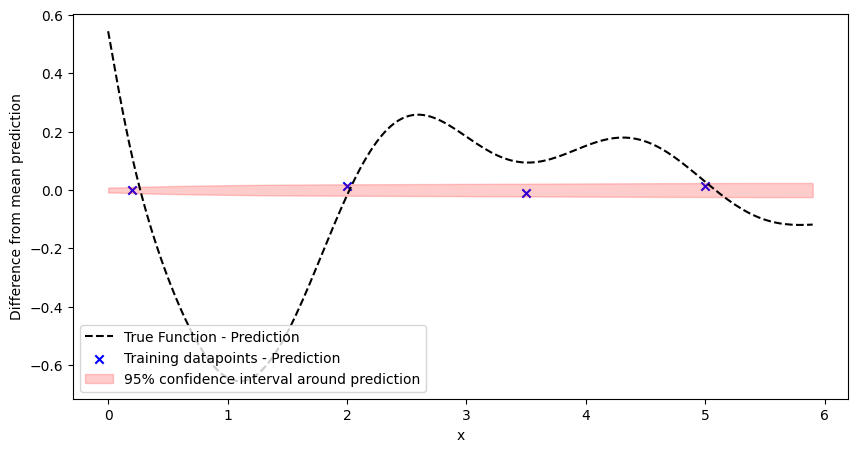

In [11]:
fig, ax = plt.subplots(figsize=(10, 5))
#plot_prediction_with_uncertainty(ax, dataloader, x_pred, y_true, y_mean, y_std)
plot_data_and_uncertainty_around_prediction(ax, x_pred, y_mean, y_true, dataloader, y_std)
plt.show()

The last ingredient we need is to choose the next optimal datapoint location using the quired uncertainty estimate.\
Thankfully, this is really easy: The most informative location is that where the uncertainty is maximal, as shown by MacKay [^1].\
This holds if the variance of all measurements is equal, and more sophisticated variants exist. \
For the sake of this tutorial, we will stick with this simple rule.

[^1]: [David J. C. MacKay, *Information-Based Objective Functions for Active Data Selection*, 1992]

In [12]:
def find_next_datapoint(x_pred, y_std):
    """Find the datapoint with largest uncertainty.

    Args:
        x_pred: Array of x values fo which uncertainty is known
        y_std: Uncertainty of x-values

    Returns:
        x-value with largest uncertainty
    """
    next_index = jnp.argmax(y_std)
    return x_pred[next_index]


next_datapoint = find_next_datapoint(x_pred, y_std)

We now plot only the uncertainty, and the x-value where it is maximal, which is our chosen next datapoint location.

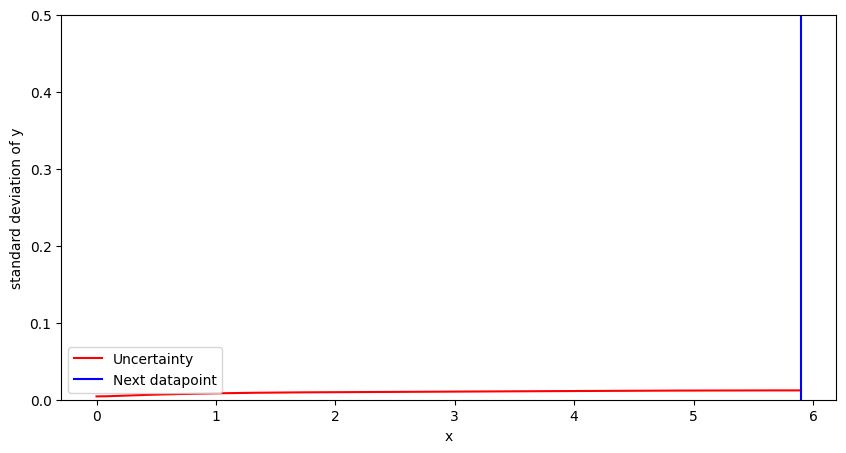

In [13]:
fig, ax = plt.subplots(figsize=(10, 5))
plot_uncertainty_and_maximum(ax, x_pred, y_std, next_datapoint)
plt.show()

Now that we have implemented and demonstrated all steps, we can implement the full active learning loop,\
iteratively sampling the next datapoint, adding it to the trainset, continuing training for 100 epochs,\
recomputing the uncertainty, and finding the next best location.

In [14]:
# Active learning loop

learning_rounds = 16

key = random.key(21780)
keys = random.split(key, learning_rounds)

subplot1_data = []
subplot2_data = []

epochs_per_learning_round = 100

for i, key in enumerate(keys):
    print(f"Active learning round {i + 1}")
    next_target = sample_target(next_datapoint, key, sample_variance=sample_variance)
    dataloader = dataloader.add(next_datapoint, next_target)
    train_model(model, dataloader, n_epochs=epochs_per_learning_round)
    y_mean, y_std = quantify_uncertainty(model, dataloader, x_pred, prior_prec)
    subplot1_data.append((dataloader, x_pred, y_true, y_mean, y_std))

    next_datapoint = find_next_datapoint(x_pred, y_std)
    subplot2_data.append((x_pred, y_std, next_datapoint))
    print("----------------------------")

Active learning round 1
Final loss: 0.0118
----------------------------
Active learning round 2
Final loss: 0.0332
----------------------------
Active learning round 3
Final loss: 0.0322
----------------------------
Active learning round 4
Final loss: 0.0339
----------------------------
Active learning round 5
Final loss: 0.0500
----------------------------
Active learning round 6
Final loss: 0.0666
----------------------------
Active learning round 7
Final loss: 0.0032
----------------------------
Active learning round 8
Final loss: 0.0029
----------------------------
Active learning round 9
Final loss: 0.0420
----------------------------
Active learning round 10
Final loss: 0.0194
----------------------------
Active learning round 11
Final loss: 0.0252
----------------------------
Active learning round 12
Final loss: 0.0462
----------------------------
Active learning round 13
Final loss: 0.0776
----------------------------
Active learning round 14
Final loss: 0.0504
----------------

In [15]:
fig, (ax1, ax2) = plt.subplots(2, sharex=True, figsize=(10, 10))


def update(frame):
    ax1.clear()
    ax2.clear()
    artists1 = plot_prediction_with_uncertainty(ax1, *(subplot1_data[frame]))
    artists2 = plot_uncertainty_and_maximum(ax2, *(subplot2_data[frame]))
    return artists1 + artists2


animation = FuncAnimation(
    fig, update, frames=learning_rounds, interval=1500, repeat_delay=2000
)
plt.close(fig)  # Prevent duplicate figure
HTML(animation.to_jshtml())

## Comparison to passive learning

To see the difference active learning makes, we compare the learned model to one that is passively trained, i.e. one where the datapoints are not chosen smartly.

For a fair comparison, we train the passive model with the same number of datapoints and for the same overall number of epochs.\
Note however that in active learning, epochs are much smaller in the beginning.
You can choose between sampling the datapoints randomly (uniform) or with deterministic equidistant spacing.

In [16]:
sampling_dropdown = widgets.Dropdown(
    options=["Random Uniform", "Equidistant"],
    value="Random Uniform",
    description="Sampling:",
)
display(sampling_dropdown)

Dropdown(description='Sampling:', options=('Random Uniform', 'Equidistant'), value='Random Uniform')

[epoch 100]: loss: 0.1304
[epoch 200]: loss: 0.1077
[epoch 300]: loss: 0.1280
[epoch 400]: loss: 0.1718
[epoch 500]: loss: 0.0771
[epoch 600]: loss: 0.0712
[epoch 700]: loss: 0.0719
[epoch 800]: loss: 0.0967
[epoch 900]: loss: 0.0823
[epoch 1000]: loss: 0.0390
[epoch 1100]: loss: 0.0734
[epoch 1200]: loss: 0.0644
[epoch 1300]: loss: 0.1412
[epoch 1400]: loss: 0.0346
[epoch 1500]: loss: 0.0371
[epoch 1600]: loss: 0.0809
[epoch 1700]: loss: 0.0471
[epoch 1800]: loss: 0.1034
[epoch 1900]: loss: 0.0532
Final loss: 0.0631


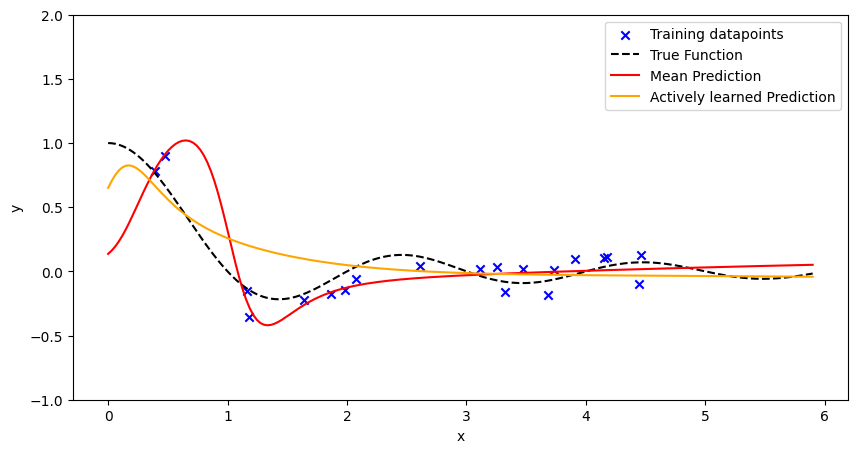

RMSE of passive model to true function: 0.43
RMSE of active model to true function: 0.14


In [17]:
n_passive_datapoints = n_initial_datapoints + learning_rounds
n_passive_epochs = n_initial_epochs + learning_rounds * epochs_per_learning_round

# Sample x-values according to selection
sampling_type = sampling_dropdown.value
random_uniform = random.uniform(key, shape=(20, 1), minval=0.2, maxval=5.0)
equidistant = jnp.linspace(0.2, 5, 20)[:, None]
passive_xs = random_uniform if sampling_type == "Random Uniform" else equidistant

# Sample y-values
keys = random.split(key, len(passive_xs))
passive_ys = vmap(sample)(passive_xs, keys)[:, None]

# Train model with sampled data
passive_dataloader = DataLoader(passive_xs, passive_ys, batch_size=10)
if len(passive_dataloader) != len(dataloader):
    print("Number of datapoints for active and passive learning do not match!")

passive_model = Model(
    in_channels=1, hidden_channels=64, out_channels=1, rngs=nnx.Rngs(seed)
)
passive_model = train_model(
    passive_model, passive_dataloader, n_epochs=n_passive_epochs
)

# Predict with passive model
y_pred_passive = passive_model(x_pred)

# Plot
fig, ax = plt.subplots(figsize=(10, 5))
plot_prediction_with_uncertainty(
    ax, passive_dataloader, x_pred, y_true, y_pred_passive, None
)
ax.plot(x_pred, y_mean, color="orange", label="Actively learned Prediction")
ax.legend()
plt.show()

# Compute RMSE to exact function
passive_rmse = jnp.sqrt(jnp.mean((y_pred_passive - y_true) ** 2))
active_rmse = jnp.sqrt(jnp.mean((y_mean - y_true) ** 2))

print(f"RMSE of passive model to true function: {passive_rmse:.2f}")
print(f"RMSE of active model to true function: {active_rmse:.2f}")

As we can see (at least in the standard configuration), the actively learned network exhibits a significantly lower RMSE than the passively learned one.